## Data loading

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import pickle

In [6]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [7]:
def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    for file in os.listdir(dataset_dir):

        # Get filename without extension
        filename = os.path.splitext(file)[0]
        filetype = os.path.splitext(file)[1]

        # Create entry if it doesn't already exist
        if filename not in data and filetype != '.pkl':
            data[filename] = {
                "image_name": None,
                "image_path": None,  
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            
            data[filename]["image_name"] = int(file.replace("bbdd_", "").replace(".jpg", ""))

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            with open(txt_path, "r", encoding="latin1") as f:
                content = f.read().strip()

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = str(lines[0])
                    data[filename]["artwork_name"] = str(lines[1])

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [8]:
df_bbdd = build_dataset(TRAIN_DIR)
print(df_bbdd.shape)
df_bbdd.head()

(287, 4)


,image_name,image_path,artist,artwork_name
0,161,data/BBDD/bbdd_00161.jpg,Anders Svarstad,"Palonetto, Sta. Lucia, Naples"
1,175,data/BBDD/bbdd_00175.jpg,Enric Barro,Trac negre i blau
2,249,data/BBDD/bbdd_00249.jpg,Narcis Comadira,Esbos per a un retaule
3,261,data/BBDD/bbdd_00261.jpg,Frederic Amat,Poema d'octubre
4,275,data/BBDD/bbdd_00275.jpg,Edvard Munch,Walter Rathenau


In [9]:
df_qsd1_w1 = build_dataset(TEST_DIR)

# erase artist and artwork_name
df_qsd1_w1 = df_qsd1_w1.drop(columns=['artist','artwork_name'])

# add correspondencies as a new colum 'ground_truth'
correspondence_path = os.path.join(TEST_DIR, "gt_corresps.pkl")
with open(correspondence_path, "rb") as file:
    correspondences = pickle.load(file)

df_qsd1_w1["ground_truth"] = (df_qsd1_w1["image_name"].map(lambda idx: correspondences[idx][0]))

print(df_qsd1_w1.shape)
df_qsd1_w1.head()

(30, 3)


,image_name,image_path,ground_truth
0,25,data/qsd1_w1/00025.jpg,38
1,19,data/qsd1_w1/00019.jpg,215
2,18,data/qsd1_w1/00018.jpg,286
3,24,data/qsd1_w1/00024.jpg,262
4,26,data/qsd1_w1/00026.jpg,238


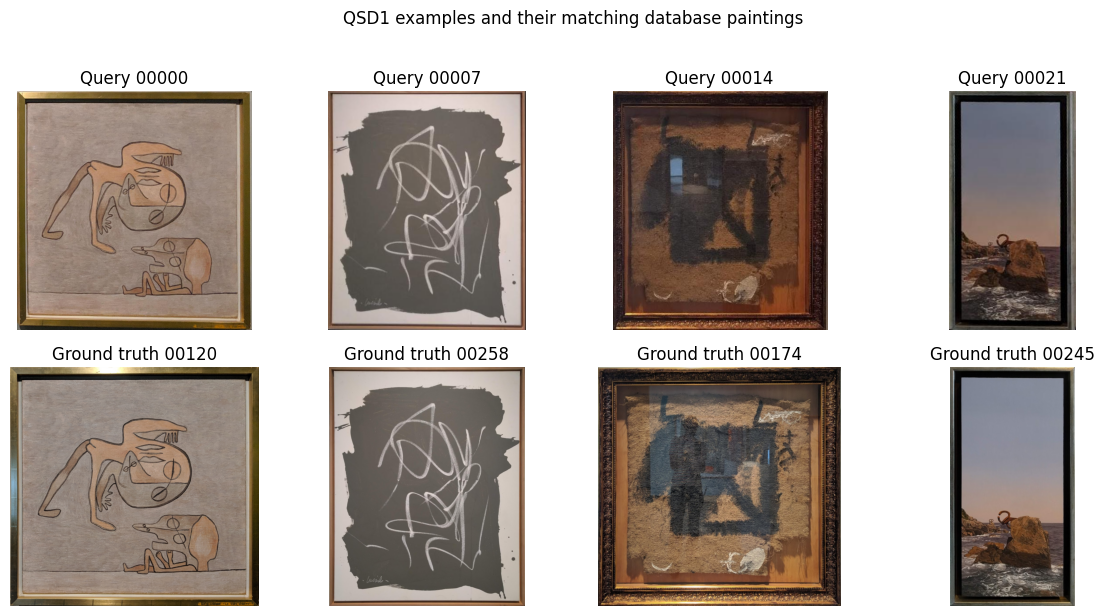

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for column, query_index in enumerate([0, 7, 14, 21]):
    query = df_qsd1_w1[df_qsd1_w1["image_name"] == query_index].iloc[0]
    gt = query["ground_truth"]
    gt_name = gt[0] if isinstance(gt, (list, tuple, np.ndarray)) else gt
    match = df_bbdd[df_bbdd["image_name"] == gt_name].iloc[0]
    axes[0, column].imshow(cv2.cvtColor(cv2.imread(query["image_path"]), cv2.COLOR_BGR2RGB))
    axes[0, column].set_title(f"Query {query_index:05d}")
    axes[1, column].imshow(cv2.cvtColor(cv2.imread(match["image_path"]), cv2.COLOR_BGR2RGB))
    axes[1, column].set_title(f"Ground truth {gt_name:05d}")

for axis in axes.flat:
    axis.axis("off")
fig.suptitle("QSD1 examples and their matching database paintings", y=1.02)
plt.tight_layout()
plt.show()

## Descriptors

We use the **HSV** and **Lab** color spaces to build the following descriptors:
- HSV 
- HSV - H
- HSV - S
- HSV - V
- LAB
- LAB - L
- LAB - A
- LAB - B

- RGB - Bins
Each descriptor is tested with:

- **Bins per channel:** `original` (one bin per possible value: 180 for H, 256 for the rest) and 16, 32, 64, 128, 256.
- **Gaussian smoothing:** σ = 0 (none), 0.5 and 1.0, measured in bins.

In [11]:
EPS = 1e-10

# OpenCV conversion code + number of possible values of each channel (8-bit images)
COLOR_SPACES = {
    "hsv": (cv2.COLOR_BGR2HSV, {"H": 180, "S": 256, "V": 256}),   # H is 0-179 in OpenCV
    "lab": (cv2.COLOR_BGR2LAB, {"L": 256, "A": 256, "B": 256}),
}

# Descriptor name -> (color space, channels it uses)
DESCRIPTORS = {}
for color_space, (_, channels) in COLOR_SPACES.items():
    DESCRIPTORS[color_space] = (color_space, list(channels))               # e.g. "hsv"   -> H, S, V
    for channel in channels:
        DESCRIPTORS[f"{color_space}_{channel.lower()}"] = (color_space, [channel])  # e.g. "hsv_h" -> H

BIN_OPTIONS = [None, 16, 32, 64, 128, 256]   # None = original (one bin per value)
SIGMA_OPTIONS = [0, 0.5, 1.0]
CIRCULAR_CHANNELS = {("hsv", "H")}           # hue wraps around: 0 and 179 are neighbours

print(list(DESCRIPTORS))

['hsv', 'hsv_h', 'hsv_s', 'hsv_v', 'lab', 'lab_l', 'lab_a', 'lab_b']


Read every image once and store the full-resolution histogram (raw pixel counts) of every channel. The rows of each array follow the order of the DataFrame.

In [12]:
def channel_histograms(image_path):
    """Full-resolution histogram (one bin per value) of every channel of every color space."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    histograms = {}
    for color_space, (code, channels) in COLOR_SPACES.items():
        converted = cv2.cvtColor(img, code)
        for ch, (name, n_values) in enumerate(channels.items()):
            counts = np.bincount(converted[..., ch].ravel(), minlength=n_values)[:n_values]
            histograms[(color_space, name)] = counts.astype(np.float64)
    return histograms


def build_histogram_bank(paths):
    """{(color_space, channel): array of shape (n_images, n_values)}, reading each image once."""
    per_image = [channel_histograms(path) for path in paths]
    return {key: np.stack([h[key] for h in per_image]) for key in per_image[0]}


bank_bbdd = build_histogram_bank(df_bbdd["image_path"])
bank_qsd1 = build_histogram_bank(df_qsd1_w1["image_path"])
{key: value.shape for key, value in bank_bbdd.items()}

{('hsv', 'H'): (287, 180),
 ('hsv', 'S'): (287, 256),
 ('hsv', 'V'): (287, 256),
 ('lab', 'L'): (287, 256),
 ('lab', 'A'): (287, 256),
 ('lab', 'B'): (287, 256)}

### Bins, smoothing and descriptor

In [13]:
def rebin_histograms(histograms, bins):
    """
    Merge full-resolution histograms (n_images, n_values) into `bins` equal-width bins.
    Value v goes to bin floor(v * bins / n_values), the same as cv2.calcHist.
    bins=None (or bins >= n_values) keeps the original histogram.
    """
    n_values = histograms.shape[1]
    if bins is None or bins >= n_values:
        return histograms

    bin_index = np.arange(n_values) * bins // n_values
    merge = np.zeros((n_values, bins))
    merge[np.arange(n_values), bin_index] = 1          # value -> bin it belongs to
    return histograms @ merge


def smooth_histograms(histograms, sigma, circular=False):
    """Apply a 1D Gaussian kernel across neighbouring bins of each histogram (row)."""
    if sigma == 0:
        return histograms

    radius = max(1, int(np.ceil(3 * sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()

    padded = np.pad(histograms, ((0, 0), (radius, radius)), mode="wrap" if circular else "reflect")
    return np.stack([np.convolve(h, kernel, mode="valid") for h in padded])


def build_descriptor(bank, descriptor, bins=None, sigma=0):
    """
    Build a descriptor for all the images of a bank.

    Returns:
    features (np.ndarray): shape (n_images, total_bins), every row sums to 1.
    channel_sizes (list[int]): number of bins of each channel (needed by EMD).
    """
    color_space, channels = DESCRIPTORS[descriptor]

    parts = []
    for channel in channels:
        h = rebin_histograms(bank[(color_space, channel)], bins)
        h = smooth_histograms(h, sigma, circular=(color_space, channel) in CIRCULAR_CHANNELS)
        h = h / (h.sum(axis=1, keepdims=True) + EPS)    # each channel sums to 1
        parts.append(h)

    features = np.concatenate(parts, axis=1) / len(parts)   # the full vector sums to 1
    return features.astype(np.float32), [p.shape[1] for p in parts]


features, sizes = build_descriptor(bank_bbdd, "hsv", bins=32, sigma=1.0)
print(features.shape, sizes, features[0].sum())

(287, 96) [32, 32, 32] 1.0


/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


### RGB using bins

Computing the histograms in rgb format and creating the bins dinamically for exploration purposes

In [14]:
def compute_histogram(img, bins=32):
    """
    Concatenated per-channel (B, G, R) histogram, normalised so that every channel sums to 1.
    Normalising makes the descriptor independent of image resolution (query and database images
    have different sizes), which is essential for Intersection and Chi-squared.
    """
    channels = []
    for c in range(3):
        h = np.histogram(img[:, :, c], bins=bins, range=(0, 256))[0].astype(np.float32)
        channels.append(h / h.sum())
    return np.concatenate(channels).astype(np.float32)

In [15]:
def create_bin_histograms(dataset, bins=32):

    """

    Return a copy of the dataset with a normalised histogram column computed with `bins` bins.

    """

    dataset = dataset.copy()

    dataset["histogram"] = dataset["image_path"].apply(

        lambda image_path: compute_histogram(cv2.imread(image_path), bins)

    )

    return dataset

Defining the similar image function for the rgb-bin-separated histograms

In [16]:
HIGHER_IS_BETTER = {cv2.HISTCMP_CORREL, cv2.HISTCMP_INTERSECT}





def find_similar_images(target_image, dataset, top_n=5, method=cv2.HISTCMP_CORREL, plot=False, bins=256):

    """

    Find the most similar images in the dataset based on histogram comparison.



    Parameters:

    target_image (np.ndarray): The target image (BGR).

    dataset (pd.DataFrame): The dataset containing images and their histograms (same `bins`).

    top_n (int): The number of most similar images to return.

    method (int): cv2.HISTCMP_* comparison method.

    plot (bool): Plot the target and the retrieved images.

    bins (int): Number of histogram bins (must match the dataset histograms).



    Returns:

    pd.DataFrame: A DataFrame containing the top N most similar images and their scores.

    """

    target_histogram = compute_histogram(target_image, bins)



    scores = dataset["histogram"].apply(

        lambda hist: cv2.compareHist(target_histogram, hist, method)

    )



    # Correlation / Intersection: high = similar. Chi-squared / Bhattacharyya: low = similar.

    ascending = method not in HIGHER_IS_BETTER

    top_scores = scores.sort_values(ascending=ascending, kind="stable").head(top_n)



    similar_images = dataset.loc[top_scores.index].copy()

    similar_images["similarity"] = top_scores



    if plot:

        plt.figure(figsize=(15, 5))

        plt.subplot(1, top_n + 1, 1)

        plt.imshow(cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB))

        plt.title("Target Image")

        plt.axis("off")



        for i, (_, row) in enumerate(similar_images.iterrows(), start=2):

            plt.subplot(1, top_n + 1, i)

            image = cv2.imread(row["image_path"])

            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

            plt.title(f"Sim: {row['similarity']:.4f}")

            plt.axis("off")



        plt.tight_layout()

        plt.show()



    return similar_images[["image_name", "image_path", "artist", "artwork_name", "similarity"]]

By performing a rather small gridsearch over all of the available distances for our RGB-bin-separated histograms we are able to see which configuration works the best given these preconditions.

In [17]:
binlist = [32, 64, 128, 256]

distance_metrics = {"Correlation": cv2.HISTCMP_CORREL,
                    "Intersect": cv2.HISTCMP_INTERSECT,
                    "Chi squared": cv2.HISTCMP_CHISQR,
                    "Battacharyya": cv2.HISTCMP_BHATTACHARYYA}

results = pd.DataFrame(columns=["bins", "distance_metric", "top1_accuracy", "top5_accuracy"])

# comparison using top 1 and top 5 accuracy with different histogram bin sizes

for bins in binlist:
    # Histograms only depend on the number of bins, so compute them once per bin size
    dataset_with_histograms = create_bin_histograms(df_bbdd, bins=bins)

    for distance_metric, method in distance_metrics.items():

        print(f"Evaluating with {bins} bins and distance metric {distance_metric}:")
        top1_correct = 0
        top5_correct = 0
        total_images = len(df_qsd1_w1)

        for _, test_row in df_qsd1_w1.iterrows():

            target_image = cv2.imread(test_row["image_path"])
            true_name = test_row["ground_truth"]

            similar_images = find_similar_images(

                target_image,
                dataset_with_histograms,
                top_n=5,
                plot=False,
                bins=bins,
                method=method,
            )

            # Check if the correct match is in the top 1
            if similar_images.iloc[0]["image_name"] == true_name:
                top1_correct += 1
                
            # Check if the correct match is in the top 5
            if true_name in similar_images["image_name"].values:
                top5_correct += 1
                
        top1_accuracy = top1_correct / total_images
        top5_accuracy = top5_correct / total_images

        results.loc[len(results)] = {

            "bins": bins,
            "distance_metric": distance_metric,
            "top1_accuracy": top1_accuracy,
            "top5_accuracy": top5_accuracy
        }

        print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
        print(f"Top-5 Accuracy: {top5_accuracy:.4f}\n")



results = results.astype({"bins": int, "top1_accuracy": float, "top5_accuracy": float})

Evaluating with 32 bins and distance metric Correlation:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 32 bins and distance metric Intersect:
Top-1 Accuracy: 0.3667
Top-5 Accuracy: 0.4667

Evaluating with 32 bins and distance metric Chi squared:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.3667

Evaluating with 32 bins and distance metric Battacharyya:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4333

Evaluating with 64 bins and distance metric Correlation:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 64 bins and distance metric Intersect:
Top-1 Accuracy: 0.3333
Top-5 Accuracy: 0.4667

Evaluating with 64 bins and distance metric Chi squared:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.3000

Evaluating with 64 bins and distance metric Battacharyya:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4333

Evaluating with 128 bins and distance metric Correlation:
Top-1 Accuracy: 0.2667
Top-5 Accuracy: 0.3667

Evaluating with 128 bins and distance metric Intersect:
Top-1 Acc

Plotting the results to see which parameters obtain the best top1 accuracy and the best acc@top5 

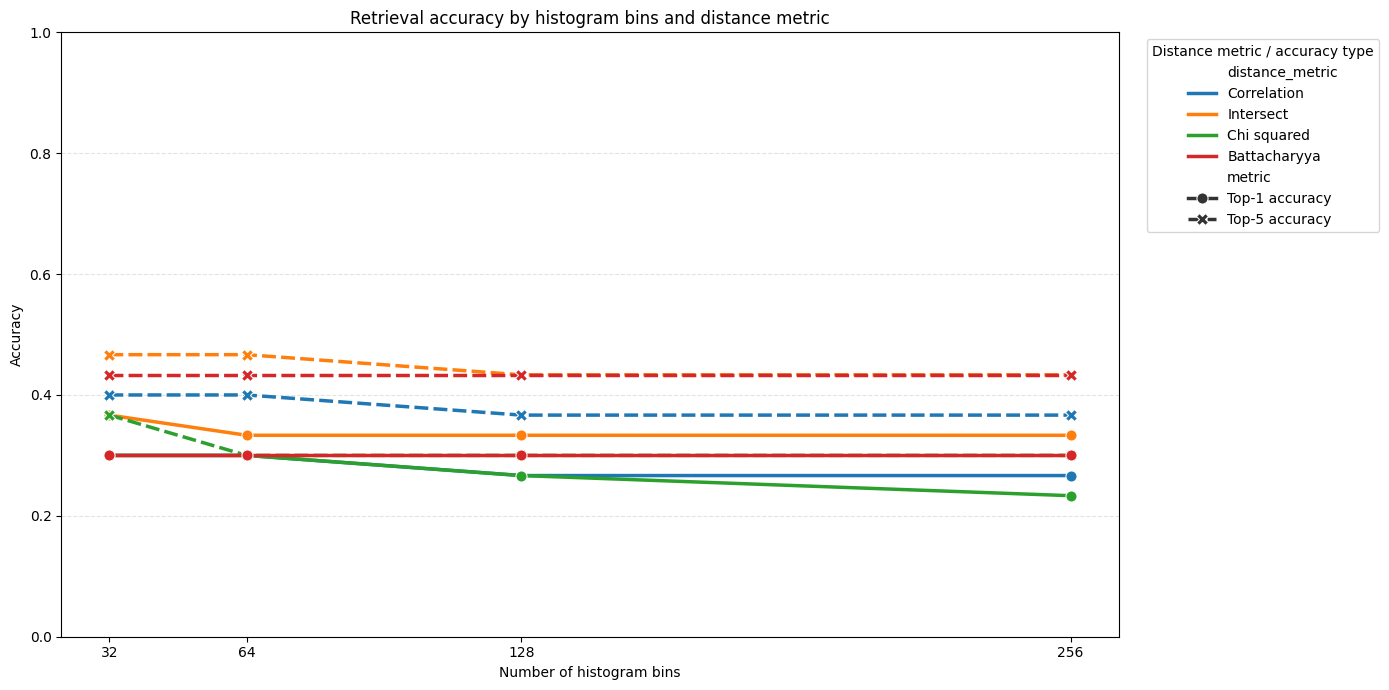

In [18]:
plot_data = results.melt(
    id_vars=["bins", "distance_metric"],
    value_vars=["top1_accuracy", "top5_accuracy"],
    var_name="metric",
    value_name="accuracy"
)
plot_data["metric"] = plot_data["metric"].map({
    "top1_accuracy": "Top-1 accuracy",
    "top5_accuracy": "Top-5 accuracy"
})

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=plot_data,
    x="bins",
    y="accuracy",
    hue="distance_metric",
    style="metric",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=8
)

plt.title("Retrieval accuracy by histogram bins and distance metric")
plt.xlabel("Number of histogram bins")
plt.ylabel("Accuracy")
plt.xticks(binlist)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Distance metric / accuracy type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Visualization

In [19]:
CHANNEL_COLORS = {
    ("hsv", "H"): "tab:purple", ("hsv", "S"): "tab:green", ("hsv", "V"): "tab:gray",
    ("lab", "L"): "tab:gray",   ("lab", "A"): "tab:red",   ("lab", "B"): "tab:blue",
}

def plot_image_histograms(df, bank, index, color_space="hsv", bins=None, sigma=0):
    """Show image `index` of df next to the per-channel histograms of its descriptor."""
    row = df.iloc[index]
    features, sizes = build_descriptor(bank, color_space, bins, sigma)
    channels = np.split(features[index] * len(sizes), np.cumsum(sizes)[:-1])  # each channel sums to 1
    names = list(COLOR_SPACES[color_space][1])

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    axes[0].imshow(cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Image {row['image_name']}")
    axes[0].axis("off")

    for ax, hist, name in zip(axes[1:], channels, names):
        n_values = COLOR_SPACES[color_space][1][name]
        width = n_values / len(hist)
        centers = np.arange(len(hist)) * width + width / 2
        sns.histplot(x=centers, weights=hist, bins=len(hist), binrange=(0, n_values),
                     color=CHANNEL_COLORS[(color_space, name)], ax=ax)
        ax.set(title=f"{color_space.upper()} - {name}", xlabel="Value", ylabel="Frequency", xlim=(0, n_values))

    bins_label = "original" if bins is None else bins
    fig.suptitle(f"{color_space.upper()} | bins = {bins_label} | sigma = {sigma}")
    fig.tight_layout()
    plt.show()

/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


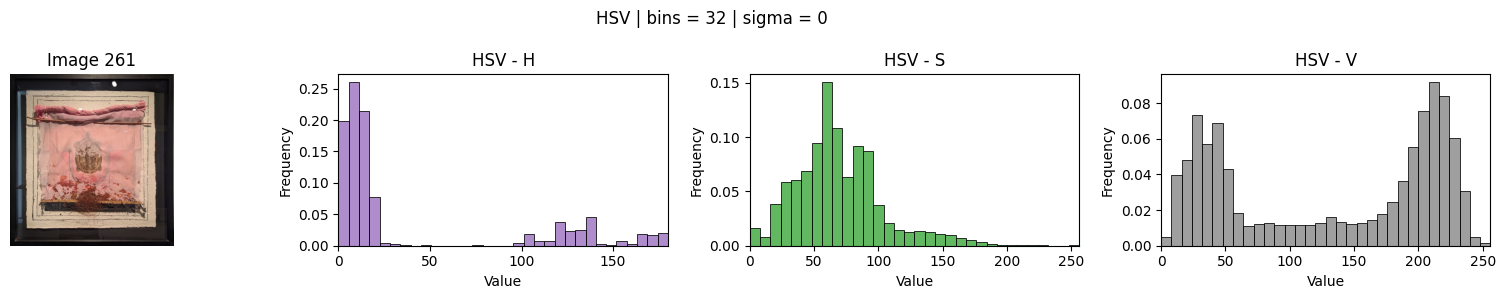

/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


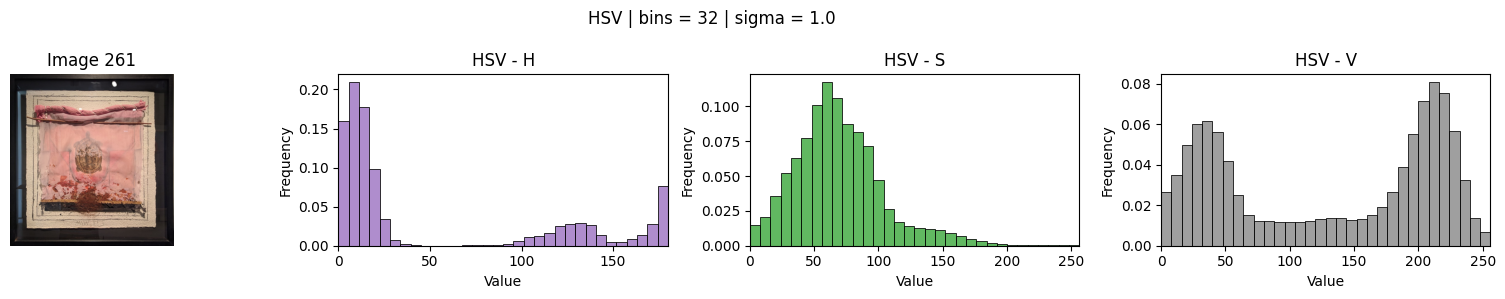

/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


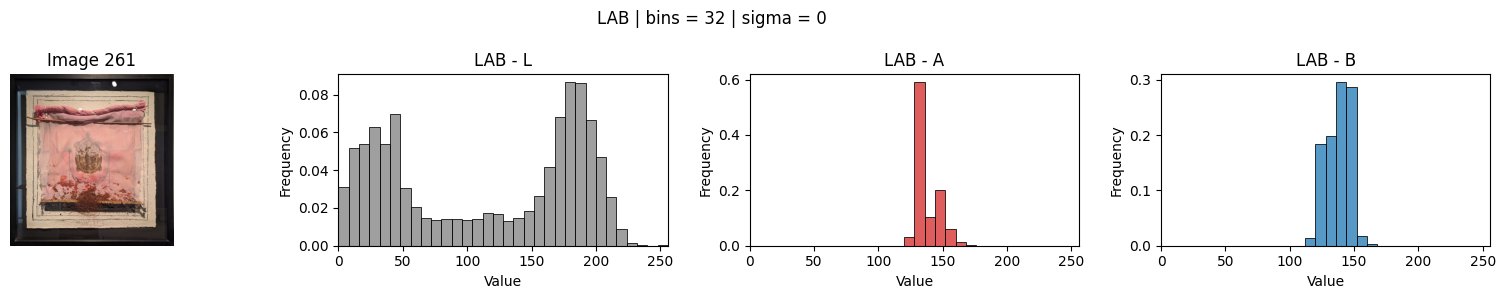

In [20]:
plot_image_histograms(df_bbdd, bank_bbdd, 3, color_space="hsv", bins=32, sigma=0)
plot_image_histograms(df_bbdd, bank_bbdd, 3, color_space="hsv", bins=32, sigma=1.0)
plot_image_histograms(df_bbdd, bank_bbdd, 3, color_space="lab", bins=32, sigma=0)

## Distances

Compare the distances: 
- euclidean
- l1
- x2
- chi_squared
- intersection
- hellinger
- bhattacharyya
- emd

In [21]:
SIMILARITIES = {"intersection", "hellinger"}                                          # higher = more similar
DISTANCES = {"euclidean", "l1", "x2", "chi_squared", "emd", "bhattacharyya"}          # lower = more similar
METRICS = sorted(SIMILARITIES | DISTANCES)


def pairwise_scores(Q, X, metric, channel_sizes):
    """Score of every query (rows of Q) against every database image (rows of X)."""
    q = Q[:, None, :].astype(np.float64)    # (n_queries, 1, D)
    x = X[None, :, :].astype(np.float64)    # (1, n_database, D)

    if metric == "euclidean":
        return np.sqrt(((q - x) ** 2).sum(axis=-1))
    if metric == "l1":
        return np.abs(q - x).sum(axis=-1)
    if metric == "x2":
        num, den = (q - x) ** 2, q + x
        return np.divide(num, den, out=np.zeros_like(num), where=den > 0).sum(axis=-1)
    if metric == "chi_squared":
        num, den = (q - x) ** 2, np.broadcast_to(q, ((q - x) ** 2).shape)
        return np.divide(num, den, out=np.zeros_like(num), where=den > 0).sum(axis=-1)
    if metric == "intersection":
        return np.minimum(q, x).sum(axis=-1)
    if metric == "hellinger":
        return np.sqrt(q * x).sum(axis=-1)
    if metric == "bhattacharyya":
        return -np.log(np.sqrt(q * x).sum(axis=-1) + EPS)
    if metric == "emd":
        splits = np.cumsum(channel_sizes)[:-1]
        total = 0.0
        for qc, xc in zip(np.split(Q, splits, axis=1), np.split(X, splits, axis=1)):
            cdf_q = np.cumsum(qc / (qc.sum(axis=1, keepdims=True) + EPS), axis=1)
            cdf_x = np.cumsum(xc / (xc.sum(axis=1, keepdims=True) + EPS), axis=1)
            total = total + np.abs(cdf_q[:, None, :] - cdf_x[None, :, :]).sum(axis=-1)
        return total

    raise ValueError(f"Unknown metric '{metric}'. Options: {METRICS}")


def rank_database(Q, X, metric, channel_sizes):
    """Database indices ordered from most to least similar for every query, plus the scores."""
    scores = pairwise_scores(Q, X, metric, channel_sizes)
    order = np.argsort(-scores if metric in SIMILARITIES else scores, axis=1, kind="stable")
    return order, scores

### Evaluation (AP@k / mAP@k)

In [22]:
def average_precision_at_k(actual, predicted, k):
    """AP@k of one query. actual: correct image_names; predicted: ranked image_names."""
    actual = list(actual) if isinstance(actual, (list, tuple, np.ndarray)) else [actual]
    hits, score = 0, 0.0
    for i, pred in enumerate(predicted[:k]):
        if pred in actual:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(actual), k)


def mean_average_precision(predicted_names, ground_truth, k):
    """mAP@k over all queries. predicted_names: (n_queries, >=k) ranked image_names."""
    return float(np.mean([average_precision_at_k(gt, pred, k)
                          for gt, pred in zip(ground_truth, predicted_names)]))

### Retrieval of one query

In [23]:
DB_NAMES = df_bbdd["image_name"].to_numpy()


def get_similar(query_index, descriptor, metric, k=5, bins=None, sigma=0, plot=False):
    """Retrieve the k most similar database images for query `query_index` of df_qsd1_w1."""
    X, sizes = build_descriptor(bank_bbdd, descriptor, bins, sigma)
    Q, _ = build_descriptor(bank_qsd1, descriptor, bins, sigma)

    order, scores = rank_database(Q[[query_index]], X, metric, sizes)
    top = order[0, :k]
    top_k = df_bbdd.iloc[top][["image_name", "artist", "artwork_name", "image_path"]].assign(score=scores[0, top])

    query = df_qsd1_w1.iloc[query_index]
    ap = average_precision_at_k(query["ground_truth"], top_k["image_name"].tolist(), k)

    if plot:
        gt = query["ground_truth"]
        gt = list(gt) if isinstance(gt, (list, tuple, np.ndarray)) else [gt]

        fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3.5))
        axes[0].imshow(cv2.cvtColor(cv2.imread(query["image_path"]), cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Query {query['image_name']:05d}\nAP@{k} = {ap:.2f}")

        for ax, (_, row) in zip(axes[1:], top_k.iterrows()):
            ax.imshow(cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB))
            ax.set_title(f"{row['image_name']:05d}\n{metric}: {row['score']:.3f}",
                         color="green" if row["image_name"] in gt else "red")

        for ax in axes:
            ax.axis("off")
        bins_label = "original" if bins is None else bins
        fig.suptitle(f"{descriptor.upper()} | bins = {bins_label} | sigma = {sigma} | {metric}")
        fig.tight_layout()
        plt.show()

    return top_k.drop(columns="image_path"), ap

/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


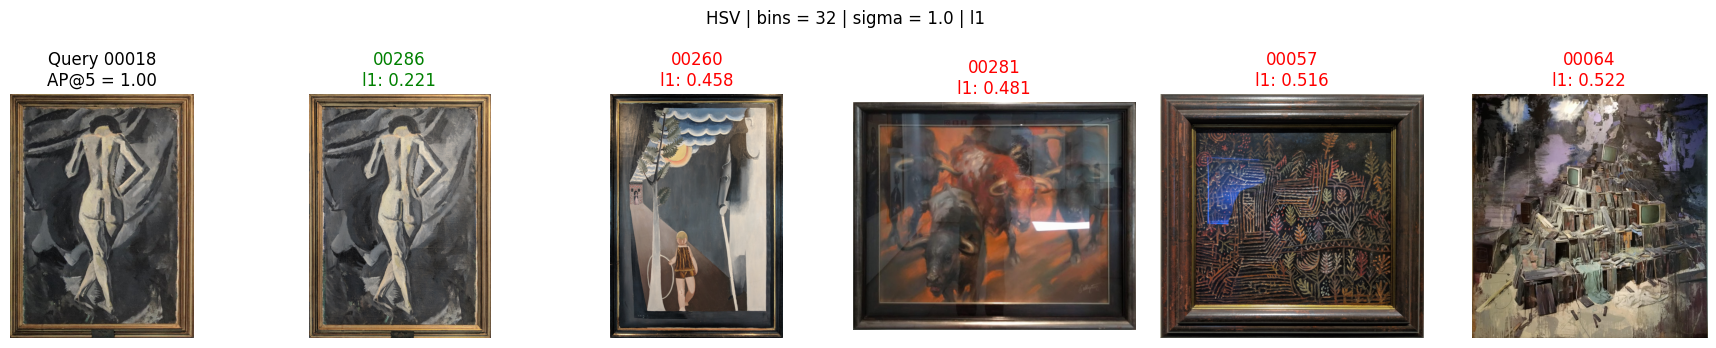

,image_name,artist,artwork_name,score
269,286,Per Krohg,Female Nude,0.221349
30,260,Per Krohg,The Stroll,0.458253
176,281,Vicenc Badalona,Braus,0.481137
137,57,Paul Klee,Untitled,0.515650
89,64,Julio Vaquero,Zigurat de misteris,0.521781


In [24]:
top_k, ap = get_similar(2, "hsv", "l1", k=5, bins=32, sigma=1.0, plot=True)
top_k

### Grid search

For every descriptor, number of bins, sigma and metric, rank the database for all the queries **once** and compute mAP@1 and mAP@5 from that same ranking.

In [25]:
def grid_search(descriptors=DESCRIPTORS, bin_options=BIN_OPTIONS, sigma_options=SIGMA_OPTIONS,
                metrics=METRICS, ks=(1, 5)):
    ground_truth = df_qsd1_w1["ground_truth"].tolist()
    results = []

    for descriptor in descriptors:
        for bins in bin_options:
            for sigma in sigma_options:
                X, sizes = build_descriptor(bank_bbdd, descriptor, bins, sigma)
                Q, _ = build_descriptor(bank_qsd1, descriptor, bins, sigma)

                for metric in metrics:
                    order, _ = rank_database(Q, X, metric, sizes)
                    predicted = DB_NAMES[order[:, :max(ks)]]

                    row = {
                        "descriptor": descriptor,
                        "bins": "original" if bins is None else str(bins),
                        "sigma": sigma,
                        "metric": metric,
                    }
                    for k in ks:
                        row[f"mAP@{k}"] = mean_average_precision(predicted, ground_truth, k)
                    results.append(row)

    return pd.DataFrame(results)


df_results = grid_search()
df_results.to_csv("grid_search_results.csv", index=False)
print(df_results.shape)
df_results.sort_values(["mAP@5", "mAP@1"], ascending=False).head(10)

/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


(1152, 6)


,descriptor,bins,sigma,metric,mAP@1,mAP@5
37,hsv,16,0.5,intersection,0.566667,0.628889
38,hsv,16,0.5,l1,0.566667,0.628889
31,hsv,16,0.0,x2,0.533333,0.603889
669,lab,64,1.0,intersection,0.533333,0.602778
670,lab,64,1.0,l1,0.533333,0.602778
653,lab,64,0.0,intersection,0.533333,0.599444
654,lab,64,0.0,l1,0.533333,0.599444
661,lab,64,0.5,intersection,0.533333,0.597222
662,lab,64,0.5,l1,0.533333,0.597222
69,hsv,32,1.0,intersection,0.500000,0.595556


# Comparison

In [26]:
# Best configuration (bins, sigma) of every descriptor + metric
best = (df_results.sort_values(["mAP@5", "mAP@1"], ascending=False)
                  .drop_duplicates(["descriptor", "metric"])
                  .reset_index(drop=True))
best.head(15)

,descriptor,bins,sigma,metric,mAP@1,mAP@5
0,hsv,16,0.5,intersection,0.566667,0.628889
1,hsv,16,0.5,l1,0.566667,0.628889
2,hsv,16,0.0,x2,0.533333,0.603889
3,lab,64,1.0,intersection,0.533333,0.602778
4,lab,64,1.0,l1,0.533333,0.602778
5,hsv,16,0.5,bhattacharyya,0.500000,0.591111
6,hsv,16,0.5,hellinger,0.500000,0.591111
7,lab,128,1.0,bhattacharyya,0.500000,0.574444
8,lab,128,1.0,hellinger,0.500000,0.574444
9,hsv,original,1.0,emd,0.466667,0.557778


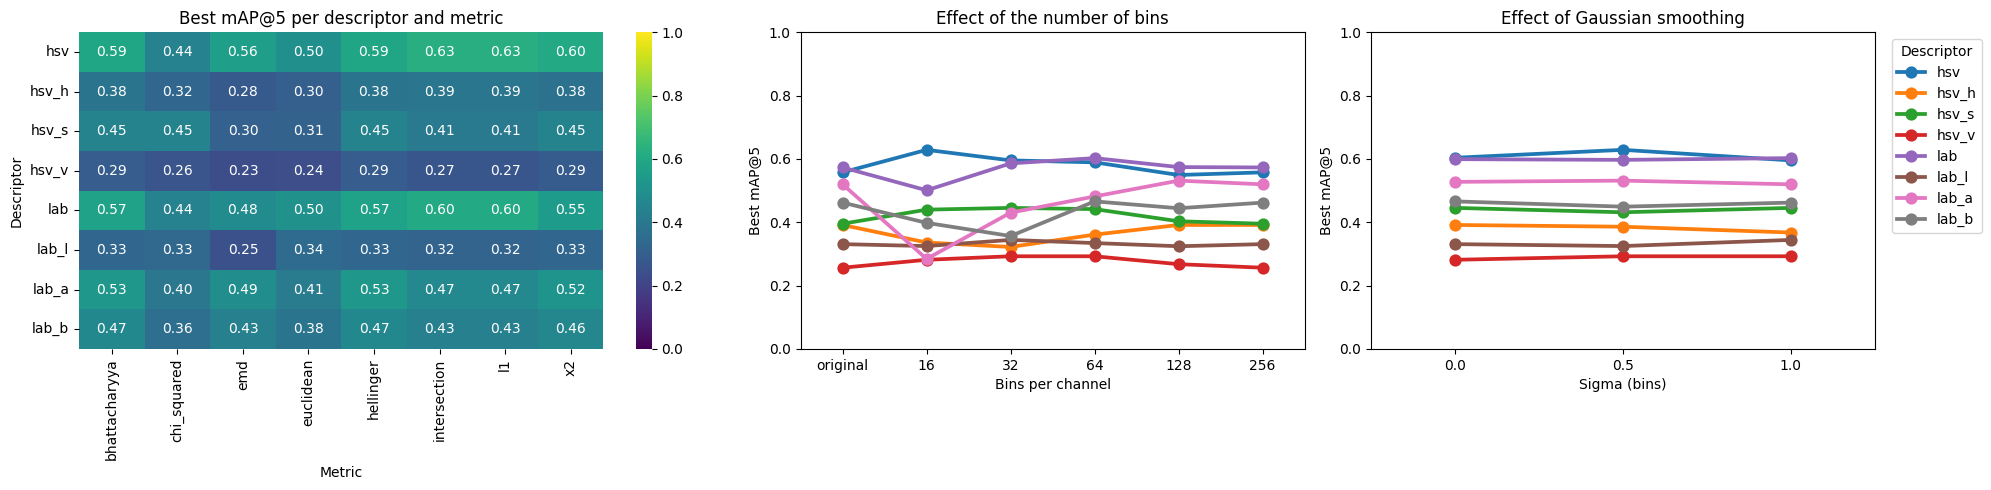

In [27]:
BIN_ORDER = ["original", "16", "32", "64", "128", "256"]
DESCRIPTOR_ORDER = list(DESCRIPTORS)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={"width_ratios": [1.3, 1, 1]})

# 1) Best mAP@5 of each descriptor and metric (over bins and sigma)
heat = df_results.pivot_table(index="descriptor", columns="metric", values="mAP@5", aggfunc="max")
sns.heatmap(heat.loc[DESCRIPTOR_ORDER], annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=axes[0])
axes[0].set(title="Best mAP@5 per descriptor and metric", xlabel="Metric", ylabel="Descriptor")
axes[0].tick_params(axis="y", rotation=0)

# 2) Effect of the number of bins (best metric and sigma for each point)
by_bins = df_results.groupby(["descriptor", "bins"], as_index=False)["mAP@5"].max()
sns.pointplot(data=by_bins, x="bins", y="mAP@5", hue="descriptor", order=BIN_ORDER,
              hue_order=DESCRIPTOR_ORDER, ax=axes[1])
axes[1].set(title="Effect of the number of bins", xlabel="Bins per channel", ylabel="Best mAP@5", ylim=(0, 1))
axes[1].get_legend().remove()

# 3) Effect of smoothing (best metric and bins for each point)
by_sigma = df_results.groupby(["descriptor", "sigma"], as_index=False)["mAP@5"].max()
sns.pointplot(data=by_sigma, x="sigma", y="mAP@5", hue="descriptor", hue_order=DESCRIPTOR_ORDER, ax=axes[2])
axes[2].set(title="Effect of Gaussian smoothing", xlabel="Sigma (bins)", ylabel="Best mAP@5", ylim=(0, 1))
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Descriptor")

fig.tight_layout()
plt.show()

## Selection of the best methods  

In order to select the two methods, we will not directly take the best row of the grid search, because QSD1 only has 30 queries and the top one can be there just by luck. So to choose the two methods...: 
- Each configuration gets a score: its mAP averaged with its neighbours (one step more or less in bins or in sigma). So a configuration only ranks high if the settings around it are good too.
- intersection and bhattacharyya give the same ranking as l1 and hellinger.
- Method 1 is the best HSV configuration and Method 2 the best Lab one.

In [28]:
import re

BIN_ORDER = ["original", "16", "32", "64", "128", "256"]
SIGMA_ORDER = [0, 0.5, 1.0]
DUPLICATES = ["intersection", "bhattacharyya"]     # they rank exactly like l1 and hellinger


def add_robust_scores(df):
    table = df.set_index(["descriptor", "metric", "bins", "sigma"])[["mAP@1", "mAP@5"]].sort_index()
    robust = []
    for descriptor, metric, bins, sigma in table.index:
        b, s = BIN_ORDER.index(bins), SIGMA_ORDER.index(sigma)
        cells = [(b, s)]
        cells += [(b + d, s) for d in (-1, 1) if 0 <= b + d < len(BIN_ORDER)]
        cells += [(b, s + d) for d in (-1, 1) if 0 <= s + d < len(SIGMA_ORDER)]
        values = [table.loc[(descriptor, metric, BIN_ORDER[i], SIGMA_ORDER[j])].to_numpy() for i, j in cells]
        robust.append(np.mean(values, axis=0))
    robust = np.array(robust)

    out = table.reset_index()
    out["robust_mAP@1"], out["robust_mAP@5"] = robust[:, 0], robust[:, 1]
    return out

In [29]:
df_robust = add_robust_scores(df_results)
candidates = df_robust[~df_robust["metric"].isin(DUPLICATES)]
SORT = ["robust_mAP@5", "robust_mAP@1"]

for descriptor in ["hsv", "lab"]:
    print(f"Best {descriptor.upper()} configurations (robust = averaged with the neighbouring settings):")
    display(candidates[candidates["descriptor"] == descriptor].sort_values(SORT, ascending=False).head(5).round(3))


def best_of(descriptor):
    r = candidates[candidates["descriptor"] == descriptor].sort_values(SORT, ascending=False).iloc[0]
    return {"descriptor": descriptor,
            "bins": None if r["bins"] == "original" else int(r["bins"]),
            "sigma": float(r["sigma"]),
            "metric": r["metric"]}


METHODS = {"method1": best_of("hsv"), "method2": best_of("lab")}
METHODS

Best HSV configurations (robust = averaged with the neighbouring settings):


,descriptor,metric,bins,sigma,mAP@1,mAP@5,robust_mAP@1,robust_mAP@5
119,hsv,l1,32,1.0,0.500,0.596,0.500,0.588
113,hsv,l1,16,1.0,0.467,0.593,0.492,0.583
112,hsv,l1,16,0.5,0.567,0.629,0.500,0.576
118,hsv,l1,32,0.5,0.533,0.573,0.500,0.572
122,hsv,l1,64,1.0,0.500,0.589,0.475,0.568


Best LAB configurations (robust = averaged with the neighbouring settings):


,descriptor,metric,bins,sigma,mAP@1,mAP@5,robust_mAP@1,robust_mAP@5
696,lab,l1,64,0.0,0.533,0.599,0.500,0.578
697,lab,l1,64,0.5,0.533,0.597,0.493,0.577
698,lab,l1,64,1.0,0.533,0.603,0.508,0.572
686,lab,l1,128,1.0,0.433,0.534,0.467,0.562
662,lab,hellinger,64,1.0,0.467,0.542,0.500,0.562


{'method1': {'descriptor': 'hsv', 'bins': 32, 'sigma': 1.0, 'metric': 'l1'},
 'method2': {'descriptor': 'lab', 'bins': 64, 'sigma': 0.0, 'metric': 'l1'}}

### Final table on QSD1

In [30]:
ground_truth = df_qsd1_w1["ground_truth"].tolist()

rows = []
for name, method in METHODS.items():
    # 1. descriptors of the museum images and of the QSD1 queries
    X, sizes = build_descriptor(bank_bbdd, method["descriptor"], method["bins"], method["sigma"])
    Q, _ = build_descriptor(bank_qsd1, method["descriptor"], method["bins"], method["sigma"])
    # 2. museum images ordered from most to least similar, for each query
    order, _ = rank_database(Q, X, method["metric"], sizes)
    # 3. ids of the top 5
    predicted = DB_NAMES[order[:, :5]]

    rows.append({"method": name, **method,
                 "mAP@1": mean_average_precision(predicted, ground_truth, 1),
                 "mAP@5": mean_average_precision(predicted, ground_truth, 5)})

final_table = pd.DataFrame(rows).round(3)
final_table

/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: divide by zero encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: overflow encountered in matmul
  return histograms @ merge
/var/folders/pp/34643w6n4cxb13gv856w0dw40000gn/T/ipykernel_61676/1650076254.py:14: RuntimeWarning: invalid value encountered in matmul
  return histograms @ merge


,method,descriptor,bins,sigma,metric,mAP@1,mAP@5
0,method1,hsv,32,1.0,l1,0.500,0.596
1,method2,lab,64,0.0,l1,0.533,0.599
